In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from HybridSuperQubits import Ferbo

In [ ]:
ferbo = Ferbo(
    Ec=20,
    El = 0.05,
    Gamma=10,
    delta_Gamma=0,
    er = 0,
    phase=0,
    dimension=200,
    flux_grouping='ABS'
)

In [ ]:
phi_grid=np.linspace(-4*np.pi, 4*np.pi, 1001)
wf = ferbo.wavefunction(which=0, phi_grid=phi_grid, representation="Andreev")
evals, evecs = ferbo.potential(phi=phi_grid)

new_wf_amplitudes = np.zeros((len(phi_grid),2), dtype=complex)
for i, phi in enumerate(phi_grid):
    # n = round(phi/ (4 * np.pi))
    # if abs(phi - 4 * np.pi * n) <= np.pi:
    #     continue
    new_wf_amplitudes[i] =  wf['amplitudes'][:,i]
    
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(phi_grid/2/np.pi, np.abs(new_wf_amplitudes[:,0])**2)
ax.plot(phi_grid/2/np.pi, np.abs(new_wf_amplitudes[:,1])**2)

In [ ]:
evecs[200]

In [ ]:
evecs[200]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(phi_grid/2/np.pi, np.real(evecs[:,0,0]))
# ax.plot(phi_grid/2/np.pi, np.real(evecs[:,1,1]))
# ax.plot(phi_grid/2/np.pi, np.real(evecs[:,0,1]))
# ax.plot(phi_grid/2/np.pi, np.real(evecs[:,1,0]))

In [ ]:
evecs[0] @ wf['amplitudes'][:,0]

In [ ]:
wf['amplitudes'][:,0]

In [ ]:
fig,ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi_grid, np.abs(wf['amplitudes'][0]))
ax.plot(phi_grid, np.abs(wf['amplitudes'][1]))
fig.tight_layout()
plt.show()

In [ ]:
ferbo = Ferbo(
    Ec=20,
    El = 0.05,
    Gamma=10,
    delta_Gamma=0,
    er = 0.8,
    phase=0,
    dimension=200,
    flux_grouping='ABS'
)
evals_count = 5
esys = ferbo.eigensys(evals_count=evals_count)
param_vals=np.linspace(-2*np.pi, 2*np.pi, 201)
phi_grid = np.linspace(-8*np.pi, 8*np.pi, 1001)
wf = list()
for i in range(evals_count):
    wf_instance = ferbo.wavefunction(which=i, phi_grid=phi_grid, esys = esys)
    wf.append(wf_instance['amplitudes'])
wf = np.array(wf)
spectrum_data = ferbo.get_spectrum_vs_paramvals(param_name='phase', param_vals=param_vals, evals_count=5)

fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
ax[0].plot(param_vals/2/np.pi, spectrum_data.energy_table)
for i in range(evals_count):
    ax[1].fill_between(phi_grid/2/np.pi, esys[0][i], np.real(wf.T[:,0,i])+ esys[0][i], color='blue', alpha = 0.5)
    ax[1].fill_between(phi_grid/2/np.pi, esys[0][i], np.real(wf.T[:,1,i])+ esys[0][i], color='red', alpha= 0.5)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def latex_style(enable = True):
    if enable:
        plt.rcParams.update(
                {
                    "font.size": 16,
                    "font.family": "serif",
                    "text.usetex": True,
                    "figure.subplot.top": 0.9,
                    "figure.subplot.right": 0.9,
                    "figure.subplot.left": 0.15,
                    "figure.subplot.bottom": 0.12,
                    "figure.subplot.hspace": 0.4,
                    "savefig.dpi": 200,
                    "savefig.format": "png",
                    "axes.titlesize": 16,
                    "axes.labelsize": 18,
                    "axes.axisbelow": True,
                    "xtick.direction": "in",
                    "ytick.direction": "in",
                    "xtick.major.size": 5,
                    "xtick.minor.size": 2.25,
                    "xtick.major.pad": 7.5,
                    "xtick.minor.pad": 7.5,
                    "ytick.major.pad": 7.5,
                    "ytick.minor.pad": 7.5,
                    "ytick.major.size": 5,
                    "ytick.minor.size": 2.25,
                    "xtick.labelsize": 16,
                    "ytick.labelsize": 16,
                    "legend.fontsize": 16,
                    "legend.framealpha": 1,
                    "figure.titlesize": 16,
                    "lines.linewidth": 2,
                })
    else:
        plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
import imageio
import io
# Parámetros fijos
Ec = 20
El = 0.05
Gamma = 10
delta_Gamma = 0
phase = 0
dimension = 200
flux_grouping = 'ABS'
evals_count = 5

param_vals = np.linspace(-2*np.pi, 2*np.pi, 201)
phi_grid = np.linspace(-8*np.pi, 8*np.pi, 1001)

# Rango de er y lista para acumular frames
ers = np.linspace(0, 2.5, 50)  # 30 frames; cámbialo si quieres más/menos
frames = []

latex_style(enable=True)
for er in ers:
    # Crea el objeto Ferbo con el er actual
    ferbo = Ferbo(
        Ec=Ec, El=El,
        Gamma=Gamma, delta_Gamma=delta_Gamma,
        er=er, phase=phase,
        dimension=dimension,
        flux_grouping=flux_grouping
    )

    # Cálculo de espectro y funciones de onda
    esys = ferbo.eigensys(evals_count=evals_count)
    wf = []
    for i in range(evals_count):
        wf_inst = ferbo.wavefunction(which=i, phi_grid=phi_grid, esys=esys)
        wf.append(wf_inst['amplitudes'])
    wf = np.array(wf)  # shape (evals_count, len(phi_grid))

    spectrum_data = ferbo.get_spectrum_vs_paramvals(
        param_name='phase',
        param_vals=param_vals,
        evals_count=evals_count
    )

    # Dibujar
    fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
    # Izquierda: espectro vs phase
    ax[0].plot(param_vals/(2*np.pi), spectrum_data.energy_table)
    ax[0].set_xlabel(r'$\phi_{\mathrm{ext}} / 2\pi$')
    ax[0].set_ylabel('Energy (GHz)')
    ax[0].set_title(rf'$\epsilon_r / \Gamma =$ {er/ferbo.Gamma:.3f}')

    # Derecha: funciones de onda desplazadas por los niveles
    for i in range(evals_count):
        nivel = esys[0][i]
        ax[1].fill_between(
            phi_grid/(2*np.pi),
            nivel,
            np.real(wf.T[:,0,i]) + nivel,
        )
        ax[2].fill_between(
            phi_grid/(2*np.pi),
            nivel,
            np.real(wf.T[:,1,i]) + nivel,
        )
    ax[1].set_xlabel(r'$\phi / 2\pi$')
    ax[2].set_xlabel(r'$\phi / 2\pi$')
    ax[1].set_ylabel(r'$\mathrm{Re}(\langle +, \phi |\Psi\rangle)$')
    ax[2].set_ylabel(r'$\mathrm{Re}(\langle -, \phi |\Psi\rangle)$')

    # Capturar el frame como imagen RGB
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    # obtenemos ARGB
    buf = np.frombuffer(fig.canvas.tostring_argb(), dtype=np.uint8)
    buf = buf.reshape((h, w, 4))
    # convertimos ARGB → RGB descartando el canal alfa
    frame = buf[:, :, [1, 2, 3]]
    frames.append(frame)
    plt.close(fig)

# Guardar el GIF
output_file = 'ferbo_er_sweep.gif'
imageio.mimsave(output_file, frames, fps=5)
print(f'GIF guardado en {output_file}')

In [ ]:
from HybridSuperQubits.operators import purity

In [ ]:
ferbo = Ferbo(
    Ec=20,
    El = 0.05,
    Gamma=10,
    delta_Gamma=0,
    er = 0.8,
    phase=0,
    dimension=200,
    flux_grouping='ABS'
)

In [ ]:
esys = ferbo.eigensys(evals_count=5)

In [ ]:
purity0_array = np.zeros(200)
purity1_array = np.zeros(200)
purity2_array = np.zeros(200)

for i, er in enumerate(np.geomspace(0.01, 40, 200)):
    ferbo.er = er
    esys = ferbo.eigensys(evals_count=5)
    rho0_trace = ferbo.reduced_density_matrix(which=0, esys=esys, subsys=1)
    rho1_trace = ferbo.reduced_density_matrix(which=1, esys=esys, subsys=1)
    rho2_trace = ferbo.reduced_density_matrix(which=2, esys=esys, subsys=1)
    purity0_array[i] = purity(rho0_trace)
    purity1_array[i] = purity(rho1_trace)
    purity2_array[i] = purity(rho2_trace)

In [ ]:
%matplotlib widget
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(np.geomspace(0.01, 40, 200), purity0_array, label=r'$|g\rangle$')
ax.plot(np.geomspace(0.01, 40, 200), purity1_array, label=r'$|e\rangle$') 
ax.plot(np.geomspace(0.01, 40, 200), purity2_array, label=r'$|f\rangle$')
ax.axvline(2.5, color='black', linestyle='--', linewidth= 0.5)
ax.axvline(0.8, color='black', linestyle='--', linewidth= 0.5)
ax.set_xlabel(r'$\epsilon_r$ (GHz)')
ax.set_ylabel('Purity')
ax.set_ylim(1/2, 1.01)
ax.set_xscale('log')
ax.legend()
ax.set_title('Purity of the reduced density matrix for er sweep')
plt.show()

In [ ]:
from HybridSuperQubits.operators import trace_distance, fidelity

In [ ]:
tdistance1 = np.zeros(200)
tdistance2 = np.zeros(200)
tdistance3 = np.zeros(200)
tdistance4 = np.zeros(200)

for i, er in enumerate(np.geomspace(0.01, 40, 200)):
    ferbo.er = er
    esys = ferbo.eigensys(evals_count=5)
    rho0_trace = ferbo.reduced_density_matrix(which=0, esys=esys, subsys=1)
    rho1_trace = ferbo.reduced_density_matrix(which=1, esys=esys, subsys=1)
    rho2_trace = ferbo.reduced_density_matrix(which=2, esys=esys, subsys=1)
    # rho3_trace = ferbo.reduced_density_matrix(which=3, esys=esys, subsys=1)
    # rho4_trace = ferbo.reduced_density_matrix(which=4, esys=esys, subsys=1)
    # tdistance1[i] = trace_distance(rho0_trace, rho1_trace)
    # tdistance2[i] = trace_distance(rho0_trace, rho2_trace)
    tdistance1[i] = fidelity(rho0_trace, rho1_trace)
    tdistance2[i] = fidelity(rho0_trace, rho2_trace)
    # tdistance3[i] = fidelity(rho0_trace, rho3_trace)
    # tdistance4[i] = fidelity(rho0_trace, rho4_trace)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(np.geomspace(0.01, 40, 200), 1 - tdistance1, label=r'$\rho_{\mathrm{red}}(|e\rangle)$')
ax.plot(np.geomspace(0.01, 40, 200), 1- tdistance2, label=r'$\rho_{\mathrm{red}}(|f\rangle)$')
# ax.plot(np.geomspace(0.01, 40, 200), 1- tdistance3, label=r'$|g\rangle$')
# ax.plot(np.geomspace(0.01, 40, 200), 1- tdistance4, label=r'$|g\rangle$')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r'$\epsilon_r$ (GHz)')
ax.set_ylabel(r'$1 - \mathcal{F}(\rho_{\mathrm{red}}(|g\rangle), \rho_{\mathrm{red}}(|\cdot\rangle))$')
ax.set_title('Infidelity of the reduced density matrix for er sweep')
plt.show()

In [22]:
ferbo = Ferbo(
    Ec=20,
    El = 0.05,
    Gamma=10,
    delta_Gamma=0,
    er = 0.8,
    phase=0,
    dimension=200,
    flux_grouping='ABS'
)

esys = ferbo.eigensys(evals_count=5)

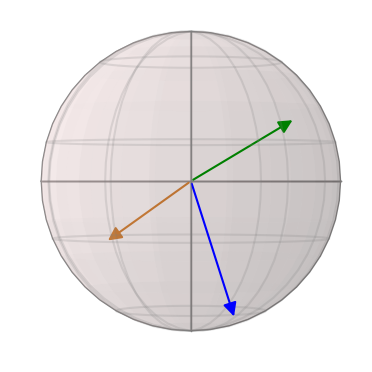

In [ ]:
from qutip import Qobj, Bloch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para ejes 3D

ferbo = Ferbo(
    Ec=20,
    El = 0.05,
    Gamma=10,
    delta_Gamma=0,
    er = 0.8,
    phase=0,
    dimension=200,
    flux_grouping='ABS'
)

esys = ferbo.eigensys(evals_count=5)

rho_reduced_0 = ferbo.reduced_density_matrix(which=0, esys=esys, subsys=1)
rho_reduced_0_qobj = Qobj(rho_reduced_0)
rho_reduced_1 = ferbo.reduced_density_matrix(which=1, esys=esys, subsys=1)
rho_reduced_1_qobj = Qobj(rho_reduced_1)
rho_reduced_2 = ferbo.reduced_density_matrix(which=2, esys=esys, subsys=1)
rho_reduced_2_qobj = Qobj(rho_reduced_2)
# Crear figura y subplots
fig = plt.figure(figsize=(10, 5))

# Eje 3D para el Bloch
ax0 = fig.add_subplot(121, projection='3d')  # eje 3D
ax0.view_init(elev = 0, azim = 0)
b = Bloch(fig=fig, axes=ax0)

b.vector_width = 1.5
b.xlabel = ["", ""]
b.ylabel = ["", ""]
b.zlabel = ["", ""]
b.add_states(state=rho_reduced_0_qobj)
b.add_states(state=rho_reduced_1_qobj)
b.add_states(state=rho_reduced_2_qobj)
b.render()

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import Qobj, Bloch
import imageio

frames = []
er_values = np.linspace(0, 5, 160)

for er in er_values:
    ferbo = Ferbo(
        Ec=20,
        El=0.05,
        Gamma=10,
        delta_Gamma=0,
        er=er,
        phase=0,
        dimension=200,
        flux_grouping='ABS'
    )
    esys = ferbo.eigensys(evals_count=5)

    rhos = [
        Qobj(ferbo.reduced_density_matrix(which=i, esys=esys, subsys=1))
        for i in range(3)
    ]

    fig = plt.figure(figsize=(6, 6))
    fig.suptitle(rf'$\epsilon_r/ \Gamma =$ {er/ferbo.Gamma:.3f}', fontsize=16)
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=0, azim=0)

    b = Bloch(fig=fig, axes=ax)
    b.vector_width = 1.5
    b.xlabel = ["", ""]
    b.ylabel = ["", ""]
    b.zlabel = ["", ""]
    for i, rho in enumerate(rhos):
        b.add_states(rho, colors=f'C{i}')
    b.render()

    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    frames.append(image)
    plt.close(fig)

imageio.mimsave("bloch_er_animation.gif", frames, fps=5)
print("GIF guardado como bloch_er_animation.gif")

GIF guardado como bloch_er_animation.gif


In [ ]:
ferbo.er = 0.8
fig, ax= plt.subplots(1,2, figsize=(10, 5))
ferbo.plot_state(which=0, plot_bloch=1, fig_ax = (fig,ax[0]))
ferbo.plot_state(which=1, plot_bloch=1, fig_ax = (fig,ax[1]))